# M2. Столкновение двух шаров на гладком столе: численный эксперимент

In [1]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import analysis
import model
import scenarios

mismatch = scenarios.check_uniform()
assert not mismatch, mismatch

S_TO_US = 1e6
M_TO_UM = 1e6
M_TO_CM = 1e2
J_TO_MJ = 1e3

PLOT_POINTS = 2001
ENERGY_PLOT_MARGIN = 0.2

HEAD_ON_SCENARIO = "head_on_rest"
HEAD_ON_SPEEDS = (0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0)

OBLIQUE_SCENARIO = "oblique_rest"
OBLIQUE_B_FRACTIONS = (0.0, 0.25, 0.5, 0.75, 0.9, 0.99)

TITLES = {
    "head_on_rest": "Лобовой, мишень покоится",
    "oblique_rest": "Косой b = (R1+R2)/2, мишень покоится",
    "grazing": "Почти вскользь b = 0.99 (R1+R2)",
    "head_on_counter": "Лобовой, навстречу",
    "catch_up": "Лобовой, догоняет",
    "unequal_radius": "Косой, R2 = 1.5 R1",
    "steel_target": "Косой, стальная мишень",
}

FIGURES = Path("report/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
THEORY_COLOR = "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2,
})

## 1. Сценарии и законы сохранения

In [2]:
names = scenarios.names()
params = {name: scenarios.get(name) for name in names}
solutions = {}
summaries = {}
for name, p in params.items():
    sol = analysis.run(p, p.FIRST_BALL, p.SECOND_BALL)
    solutions[name] = sol
    summaries[name] = analysis.collision_summary(sol, p.FIRST_BALL, p.SECOND_BALL)

def vector(v):
    return f"({v[0]:+.6f}, {v[1]:+.6f})"

for name, s in summaries.items():
    p = params[name]
    print(f"{TITLES[name]}   [scenarios/{name}.py]")
    print(f"  массы, кг:          m1 = {p.FIRST_BALL.mass:.4f}, m2 = {p.SECOND_BALL.mass:.4f}")
    print(f"  шар 1, м/с:         {vector(s['v1_before'])} -> {vector(s['v1_after'])}")
    print(f"  шар 2, м/с:         {vector(s['v2_before'])} -> {vector(s['v2_after'])}")
    print(f"  dp (отн.):          {s['momentum_change']:.1e}")
    print(f"  dK/K:               {s['energy_change']:+.1e}")
    print(f"  контакт, мкс:       {s['contact_duration'] * S_TO_US:.1f}")
    print(f"  макс. сжатие, мкм:  {s['max_compression'] * M_TO_UM:.2f}")
    print(f"  шагов решателя:     {s['steps']}")
    print()

Лобовой, мишень покоится   [scenarios/head_on_rest.py]
  массы, кг:          m1 = 0.1697, m2 = 0.1697
  шар 1, м/с:         (+1.000000, +0.000000) -> (+0.000000, +0.000000)
  шар 2, м/с:         (+0.000000, +0.000000) -> (+1.000000, +0.000000)
  dp (отн.):          1.6e-16
  dK/K:               -4.6e-10
  контакт, мкс:       452.1
  макс. сжатие, мкм:  153.59
  шагов решателя:     371

Косой b = (R1+R2)/2, мишень покоится   [scenarios/oblique_rest.py]
  массы, кг:          m1 = 0.1697, m2 = 0.1697
  шар 1, м/с:         (+1.000000, +0.000000) -> (+0.251774, -0.434032)
  шар 2, м/с:         (+0.000000, +0.000000) -> (+0.748226, +0.434032)
  dp (отн.):          1.6e-16
  dK/K:               -5.4e-09
  контакт, мкс:       465.1
  макс. сжатие, мкм:  136.81
  шагов решателя:     415

Почти вскользь b = 0.99 (R1+R2)   [scenarios/grazing.py]
  массы, кг:          m1 = 0.1697, m2 = 0.1697
  шар 1, м/с:         (+1.000000, +0.000000) -> (+0.981674, -0.134126)
  шар 2, м/с:         (+0.000000, +

## 2. Траектории центров

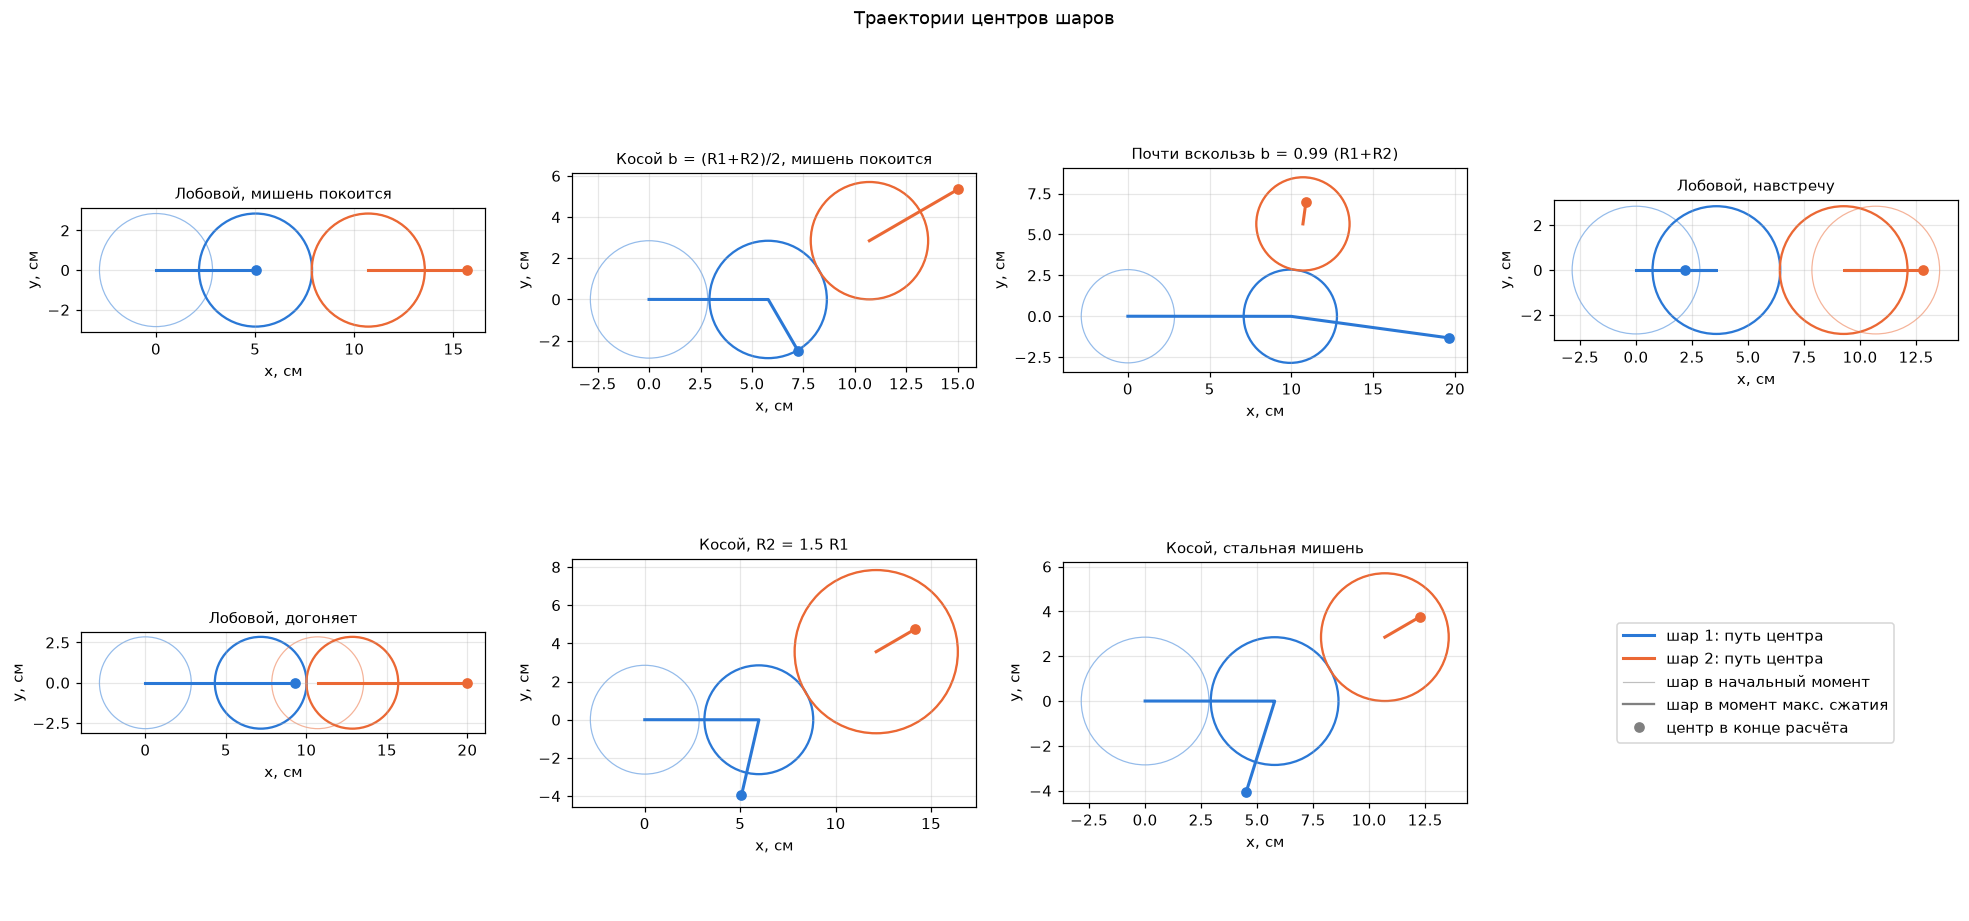

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
axes = axes.ravel()

for ax, name in zip(axes, names):
    p = params[name]
    sol = solutions[name]
    y_peak = sol.sol(summaries[name]["peak_time"])

    for label, ball, rows, color in [
        ("шар 1", p.FIRST_BALL, slice(0, 2), COLORS[0]),
        ("шар 2", p.SECOND_BALL, slice(4, 6), COLORS[1]),
    ]:
        x, y = sol.y[rows] * M_TO_CM
        ax.plot(x, y, color=color, label=f"{label}: путь центра")
        ax.add_patch(plt.Circle(
            sol.y[rows, 0] * M_TO_CM, ball.radius * M_TO_CM,
            fill=False, color=color, linewidth=0.8, alpha=0.5))
        ax.add_patch(plt.Circle(
            y_peak[rows] * M_TO_CM, ball.radius * M_TO_CM,
            fill=False, color=color, linewidth=1.5))
        ax.plot(*(sol.y[rows, -1] * M_TO_CM), "o", color=color, markersize=6)

    ax.set_aspect("equal")
    ax.set_title(TITLES[name], fontsize=10)
    ax.set_xlabel("x, см")
    ax.set_ylabel("y, см")

legend_ax = axes[len(names)]
for ax in axes[len(names):]:
    ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles + [plt.Line2D([], [], color="gray", linewidth=0.8, alpha=0.5),
               plt.Line2D([], [], color="gray", linewidth=1.5),
               plt.Line2D([], [], color="gray", marker="o", linestyle="")],
    labels + ["шар в начальный момент", "шар в момент макс. сжатия",
              "центр в конце расчёта"],
    loc="center")
fig.suptitle("Траектории центров шаров")
fig.tight_layout()
fig.savefig(FIGURES / "trajectories.png")
plt.show()

## 3. Глубина сжатия во время контакта

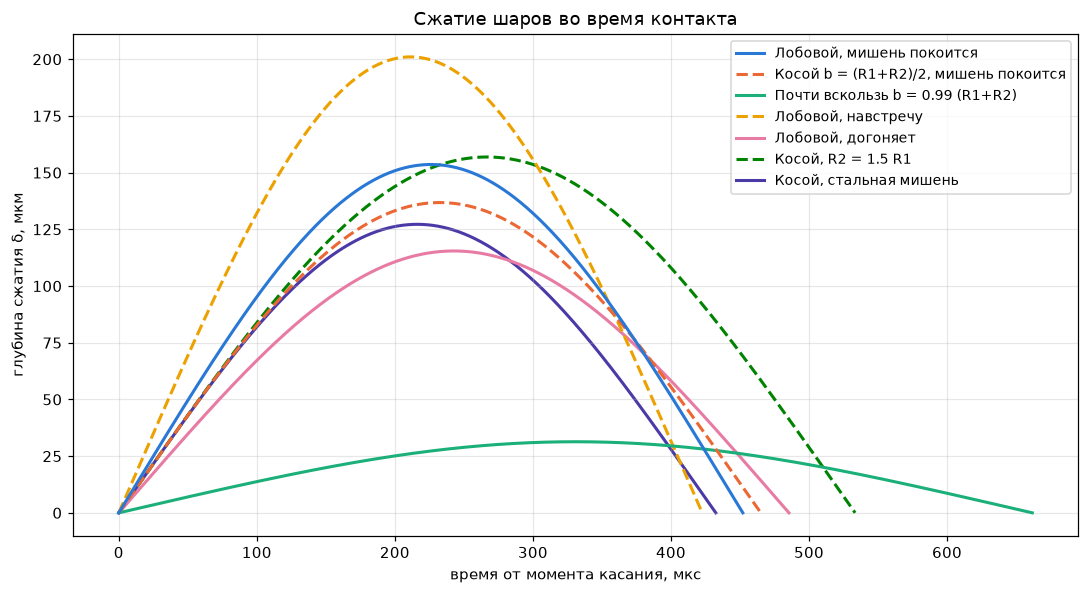

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

count = len(names)
for i, name in enumerate(names):
    p = params[name]
    s = summaries[name]
    t = np.linspace(s["contact_start"], s["contact_end"], PLOT_POINTS)
    depth = analysis.depth(solutions[name].sol(t), p.FIRST_BALL.radius, p.SECOND_BALL.radius)
    ax.plot((t - s["contact_start"]) * S_TO_US, depth * M_TO_UM, color=COLORS[i],
            linestyle="-" if i % 2 == 0 else "--", zorder=count - i, label=TITLES[name])

ax.set_xlabel("время от момента касания, мкс")
ax.set_ylabel("глубина сжатия δ, мкм")
ax.set_title("Сжатие шаров во время контакта")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "compression.png")
plt.show()

## 4. Энергия во время контакта

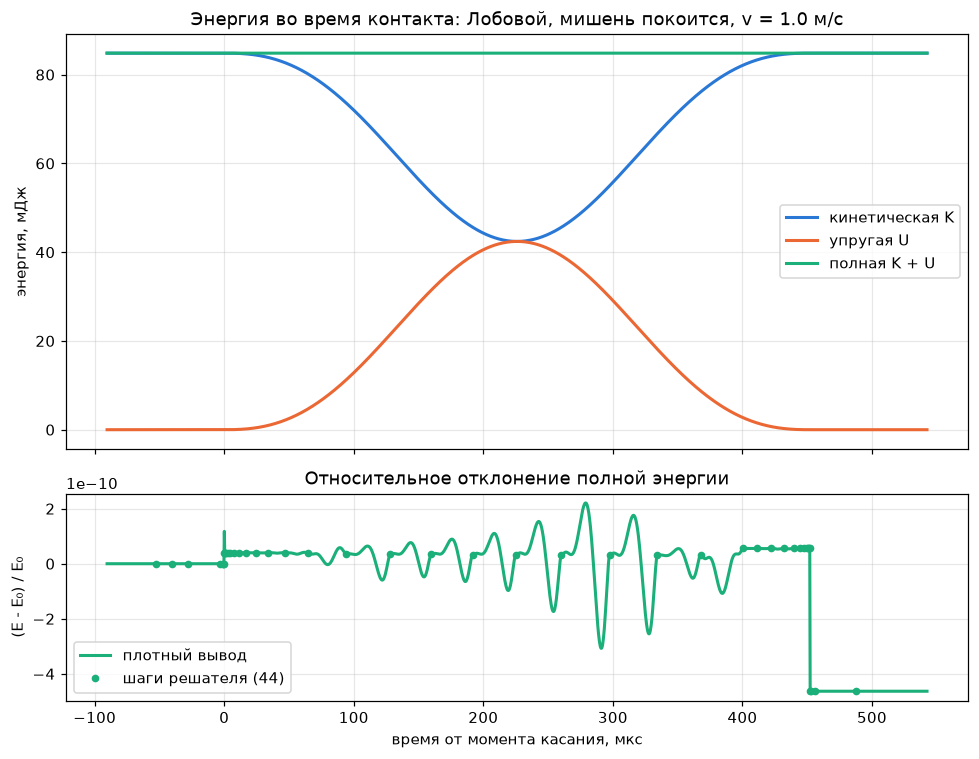

max |E - E0| / E0 = 4.6e-10


In [5]:
name = "head_on_rest"
p = params[name]
ball1, ball2 = p.FIRST_BALL, p.SECOND_BALL
sol = solutions[name]
s = summaries[name]
k = analysis.pair_stiffness(ball1, ball2)

def energies(y):
    kinetic = analysis.kinetic_energy(y, ball1.mass, ball2.mass)
    potential = analysis.potential_energy(y, ball1.radius, ball2.radius, k, p.HERTZ_EXPONENT)
    return kinetic, potential

margin = ENERGY_PLOT_MARGIN * s["contact_duration"]
t_from, t_to = s["contact_start"] - margin, s["contact_end"] + margin
t = np.linspace(t_from, t_to, PLOT_POINTS)
kinetic, potential = energies(sol.sol(t))
total = kinetic + potential
kinetic_0, potential_0 = energies(sol.y[:, 0])
energy_0 = kinetic_0 + potential_0
drift = (total - energy_0) / energy_0

steps = (sol.t >= t_from) & (sol.t <= t_to)
kinetic_steps, potential_steps = energies(sol.y[:, steps])
step_drift = (kinetic_steps + potential_steps - energy_0) / energy_0

fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
time_us = (t - s["contact_start"]) * S_TO_US

top.plot(time_us, kinetic * J_TO_MJ, color=COLORS[0], label="кинетическая K")
top.plot(time_us, potential * J_TO_MJ, color=COLORS[1], label="упругая U")
top.plot(time_us, total * J_TO_MJ, color=COLORS[2], label="полная K + U")
top.set_ylabel("энергия, мДж")
top.set_title(f"Энергия во время контакта: {TITLES[name]}, v = {ball1.velocity[0]} м/с")
top.legend()

bottom.plot(time_us, drift, color=COLORS[2], label="плотный вывод")
bottom.plot((sol.t[steps] - s["contact_start"]) * S_TO_US, step_drift, "o",
            color=COLORS[2], markersize=4, label=f"шаги решателя ({steps.sum()})")
bottom.set_xlabel("время от момента касания, мкс")
bottom.set_ylabel("(E - E₀) / E₀")
bottom.set_title("Относительное отклонение полной энергии")
bottom.legend()

fig.tight_layout()
fig.savefig(FIGURES / "energy.png")
plt.show()

print(f"max |E - E0| / E0 = {np.max(np.abs(drift)):.1e}")

## 5. Лобовые удары при разных скоростях

In [6]:
params = scenarios.get(HEAD_ON_SCENARIO)
n = params.HERTZ_EXPONENT
speeds = np.array(HEAD_ON_SPEEDS)
x_max = np.zeros(len(speeds))
x_max_theory = np.zeros(len(speeds))
tau = np.zeros(len(speeds))
steps = np.zeros(len(speeds), dtype=int)

for i, speed in enumerate(speeds):
    ball1 = replace(params.FIRST_BALL, velocity=(speed, 0.0))
    ball2 = replace(params.SECOND_BALL, velocity=(0.0, 0.0))
    k = analysis.pair_stiffness(ball1, ball2)
    mu = model.reduced_mass(ball1.mass, ball2.mass)

    sol = analysis.run(params, ball1, ball2)
    t_start, t_end = analysis.contact_interval(sol, ball1.radius, ball2.radius)
    _, x_max[i] = analysis.peak_compression(sol, t_start, t_end, ball1.radius, ball2.radius)

    x_max_theory[i] = model.max_compression(mu, speed, k, n)
    tau[i] = t_end - t_start
    steps[i] = len(sol.t)

print(" v, м/с   x_max, мкм   отн. откл.   tau, мкс   шагов")
for i in range(len(speeds)):
    print(f"{speeds[i]:7.2f}   {x_max[i] * M_TO_UM:10.4f}   {x_max[i] / x_max_theory[i] - 1:+.1e}"
          f"   {tau[i] * S_TO_US:8.3f}   {steps[i]:5d}")

slope_x = analysis.loglog_slope(speeds, x_max)
slope_tau = analysis.loglog_slope(speeds, tau)
slope_x_theory = 2 / (n + 1)
slope_tau_theory = (1 - n) / (1 + n)
print()
print(f"наклон x_max(v): численный {slope_x:.6f}, теория 2/(n+1) = {slope_x_theory:.6f}")
print(f"наклон tau(v):   численный {slope_tau:+.6f}, теория (1-n)/(1+n) = {slope_tau_theory:+.6f}")

 v, м/с   x_max, мкм   отн. откл.   tau, мкс   шагов
   0.01       3.8580   -3.7e-09   1135.523   12987
   0.02       6.7172   -1.7e-09    988.530    7478
   0.05      13.9811   -2.8e-09    823.004    3611
   0.10      24.3425   -4.3e-11    716.466    2086
   0.20      42.3826   -2.6e-06    623.720    1213
   0.50      88.2147   -1.0e-10    519.280     607
   1.00     153.5907   +2.7e-11    452.060     371
   2.00     267.4169   -1.1e-10    393.541     234

наклон x_max(v): численный 0.800000, теория 2/(n+1) = 0.800000
наклон tau(v):   численный -0.200000, теория (1-n)/(1+n) = -0.200000


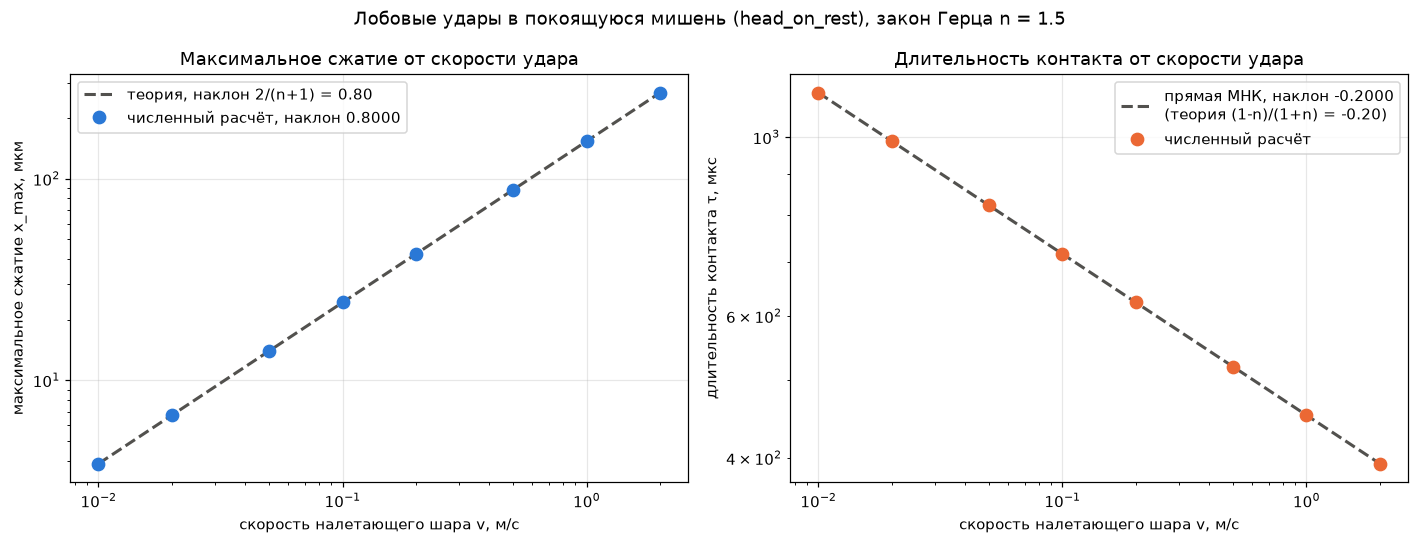

In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5))

left.loglog(speeds, x_max_theory * M_TO_UM, color=THEORY_COLOR, linestyle="--",
            label=f"теория, наклон 2/(n+1) = {slope_x_theory:.2f}")
left.loglog(speeds, x_max * M_TO_UM, "o", color=COLORS[0], markersize=8,
            label=f"численный расчёт, наклон {slope_x:.4f}")
left.set_xlabel("скорость налетающего шара v, м/с")
left.set_ylabel("максимальное сжатие x_max, мкм")
left.set_title("Максимальное сжатие от скорости удара")
left.legend()

tau_fit = np.exp(np.polyval(np.polyfit(np.log(speeds), np.log(tau), 1), np.log(speeds)))
right.loglog(speeds, tau_fit * S_TO_US, color=THEORY_COLOR, linestyle="--",
             label=f"прямая МНК, наклон {slope_tau:+.4f}\n(теория (1-n)/(1+n) = {slope_tau_theory:+.2f})")
right.loglog(speeds, tau * S_TO_US, "o", color=COLORS[1], markersize=8,
             label="численный расчёт")
right.set_xlabel("скорость налетающего шара v, м/с")
right.set_ylabel("длительность контакта τ, мкс")
right.set_title("Длительность контакта от скорости удара")
right.legend()

fig.suptitle(f"Лобовые удары в покоящуюся мишень ({HEAD_ON_SCENARIO}), закон Герца n = {n}")
fig.tight_layout()
fig.savefig(FIGURES / "head_on_loglog.png")
plt.show()

## 6. Сравнение с законами сохранения при косых ударах

In [8]:
def oblique_theory(sina, m1, m2, v0):
    cosa = np.sqrt(1 - sina**2)
    A = cosa * (m1 - m2) / (m1 + m2)
    B = cosa * 2 * m1 / (m1 + m2)
    v1 = v0 * np.array([A * cosa + sina * sina, A * sina - sina * cosa])
    v2 = v0 * np.array([B * cosa, B * sina])
    return v1, v2


def deflection_angle(v):
    speed = np.linalg.norm(v, axis=0)
    return np.degrees(np.arccos(np.clip(v[0] / speed, -1.0, 1.0)))


params = scenarios.get(OBLIQUE_SCENARIO)
ball1 = params.FIRST_BALL
m1 = ball1.mass
m2 = params.SECOND_BALL.mass
v0 = ball1.velocity[0]
contact = ball1.radius + params.SECOND_BALL.radius

b_fractions = np.array(OBLIQUE_B_FRACTIONS)
v1_num = np.zeros((2, len(b_fractions)))
v2_num = np.zeros((2, len(b_fractions)))

for i, b_fraction in enumerate(b_fractions):
    b = b_fraction * contact
    ball2 = replace(params.SECOND_BALL,
                    position=(params.SECOND_BALL.position[0], ball1.position[1] + b),
                    velocity=(0.0, 0.0))
    sol = analysis.run(params, ball1, ball2)
    v1_num[:, i] = sol.y[2:4, -1]
    v2_num[:, i] = sol.y[6:8, -1]

v1_theory, v2_theory = oblique_theory(b_fractions, m1, m2, v0)
deviation = np.maximum(np.max(np.abs(v1_num - v1_theory), axis=0),
                       np.max(np.abs(v2_num - v2_theory), axis=0)) / abs(v0)

print(f"Сценарий {OBLIQUE_SCENARIO}: v0 = {v0} м/с, m1 = {m1:.4f} кг, m2 = {m2:.4f} кг")
print()
print(" b/(R1+R2)       v1' числ.            v1' теор.            v2' числ.            v2' теор.       max|dv|/v0")
for i, b_fraction in enumerate(b_fractions):
    print(f"{b_fraction:9.2f}   ({v1_num[0, i]:+.5f}, {v1_num[1, i]:+.5f})   ({v1_theory[0, i]:+.5f}, {v1_theory[1, i]:+.5f})"
          f"   ({v2_num[0, i]:+.5f}, {v2_num[1, i]:+.5f})   ({v2_theory[0, i]:+.5f}, {v2_theory[1, i]:+.5f})"
          f"   {deviation[i]:.1e}")

Сценарий oblique_rest: v0 = 1.0 м/с, m1 = 0.1697 кг, m2 = 0.1697 кг

 b/(R1+R2)       v1' числ.            v1' теор.            v2' числ.            v2' теор.       max|dv|/v0
     0.00   (+0.00000, +0.00000)   (+0.00000, +0.00000)   (+1.00000, +0.00000)   (+1.00000, +0.00000)   2.3e-10
     0.25   (+0.06299, -0.24294)   (+0.06250, -0.24206)   (+0.93701, +0.24294)   (+0.93750, +0.24206)   8.8e-04
     0.50   (+0.25177, -0.43403)   (+0.25000, -0.43301)   (+0.74823, +0.43403)   (+0.75000, +0.43301)   1.8e-03
     0.75   (+0.56571, -0.49566)   (+0.56250, -0.49608)   (+0.43429, +0.49566)   (+0.43750, +0.49608)   3.2e-03
     0.90   (+0.81329, -0.38968)   (+0.81000, -0.39230)   (+0.18671, +0.38968)   (+0.19000, +0.39230)   3.3e-03
     0.99   (+0.98167, -0.13413)   (+0.98010, -0.13966)   (+0.01833, +0.13413)   (+0.01990, +0.13966)   5.5e-03


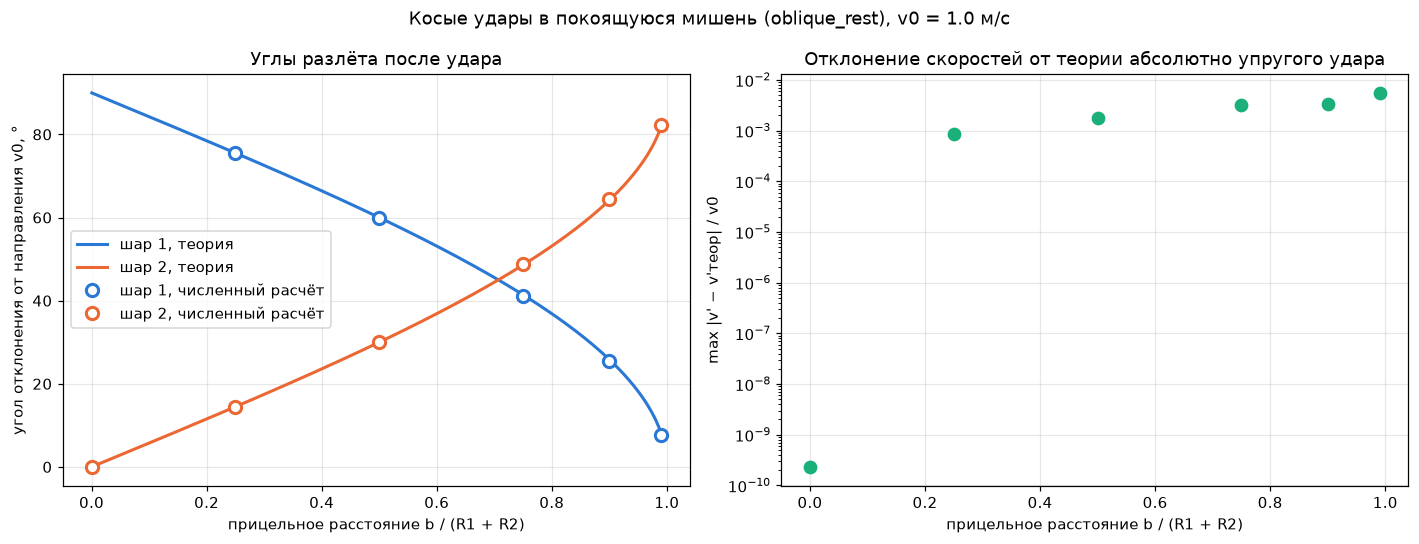

In [9]:
b_line = np.linspace(0.0, max(OBLIQUE_B_FRACTIONS), PLOT_POINTS)
v1_line, v2_line = oblique_theory(b_line, m1, m2, v0)

moving1 = np.linalg.norm(v1_num, axis=0) > 1e-6 * abs(v0)
moving1_line = np.linalg.norm(v1_line, axis=0) > 1e-6 * abs(v0)

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5))

left.plot(b_line[moving1_line], deflection_angle(v1_line[:, moving1_line]), color=COLORS[0],
          label="шар 1, теория")
left.plot(b_line, deflection_angle(v2_line), color=COLORS[1], label="шар 2, теория")
left.plot(b_fractions[moving1], deflection_angle(v1_num[:, moving1]), "o", color=COLORS[0],
          markersize=8, markerfacecolor="white", markeredgewidth=2, label="шар 1, численный расчёт")
left.plot(b_fractions, deflection_angle(v2_num), "o", color=COLORS[1],
          markersize=8, markerfacecolor="white", markeredgewidth=2, label="шар 2, численный расчёт")
left.set_xlabel("прицельное расстояние b / (R1 + R2)")
left.set_ylabel("угол отклонения от направления v0, °")
left.set_title("Углы разлёта после удара")
left.legend()

right.semilogy(b_fractions, deviation, "o", color=COLORS[2], markersize=8)
right.set_xlabel("прицельное расстояние b / (R1 + R2)")
right.set_ylabel("max |v' − v'теор| / v0")
right.set_title("Отклонение скоростей от теории абсолютно упругого удара")

fig.suptitle(f"Косые удары в покоящуюся мишень ({OBLIQUE_SCENARIO}), v0 = {v0} м/с")
fig.tight_layout()
fig.savefig(FIGURES / "oblique_angles.png")
plt.show()